In [27]:
import numpy as np
import xarray as xr
import time
import os
import glob
from typing import Tuple, List, Dict, Optional
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from scipy import signal, fft
import cmaps
import sys
from pathlib import Path
import psutil
import gc

WAVE_TOOLS_PATH = Path("/work/mh1498/m301257/wave_tools")
sys.path.insert(0, str(WAVE_TOOLS_PATH.parent))
from wave_tools.utils import dataarray_healpix_to_equatorial_latlon
from wave_tools import calculate_cross_spectrum, quick_cross_spectrum
from wave_tools.utils import  get_curve

# ============ 内存监控工具 ============
class MemoryMonitor:
    """内存监控类"""
    def __init__(self):
        self.process = psutil.Process()
        
    def get_memory_info(self):
        """获取当前内存使用信息"""
        mem = self.process.memory_info()
        mem_percent = self.process.memory_percent()
        virtual_mem = psutil.virtual_memory()
        
        return {
            'rss_gb': mem.rss / 1024**3,  # 物理内存 (GB)
            'vms_gb': mem.vms / 1024**3,  # 虚拟内存 (GB)
            'percent': mem_percent,        # 进程内存占用百分比
            'available_gb': virtual_mem.available / 1024**3,  # 系统可用内存 (GB)
            'total_gb': virtual_mem.total / 1024**3           # 系统总内存 (GB)
        }
    
    def print_memory_status(self, label=""):
        """打印内存状态"""
        info = self.get_memory_info()
        print(f"\n{'='*60}")
        print(f"💾 内存状态 {f'- {label}' if label else ''}")
        print(f"{'='*60}")
        print(f"  进程物理内存使用: {info['rss_gb']:.2f} GB")
        print(f"  进程虚拟内存使用: {info['vms_gb']:.2f} GB")
        print(f"  进程内存占比: {info['percent']:.1f}%")
        print(f"  系统可用内存: {info['available_gb']:.2f} GB / {info['total_gb']:.2f} GB")
        print(f"{'='*60}\n")
        
        # 如果可用内存不足10GB，发出警告
        if info['available_gb'] < 10:
            print("⚠️  警告: 系统可用内存不足10GB!")
        
        return info

# 创建全局内存监控器
mem_monitor = MemoryMonitor()

def dataarray_to_equatorial_latlon_grid(
    dataarray: xr.DataArray, grid_type: str, grid_dict: Optional[dict]
) -> xr.DataArray:
    """转换数据到赤道经纬度网格"""
    if grid_type == "latlon":
        return dataarray
    elif grid_type == "healpix":
        if grid_dict is None:
            raise ValueError("No grid_dict provided for healpix conversion.")
        return dataarray_healpix_to_equatorial_latlon(dataarray, **grid_dict)
    else:
        raise ValueError("Grid type not found.")

FIG_SAVE_DIR = "../figures/cross_spectrum_specific_layer_55/"

# 创建必要的目录
for d in [FIG_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)

EXPERIMENTS = ['CNTL', 'P4K', '4CO2']

# 初始内存状态
mem_monitor.print_memory_status("初始化")



💾 内存状态 - 初始化
  进程物理内存使用: 14.89 GB
  进程虚拟内存使用: 39.41 GB
  进程内存占比: 3.0%
  系统可用内存: 201.89 GB / 501.87 GB



{'rss_gb': 14.894306182861328,
 'vms_gb': 39.40796661376953,
 'percent': 2.967750399495784,
 'available_gb': 201.8907470703125,
 'total_gb': 501.8719291687012}

In [2]:
# ============ 加载降水数据 ============

def load_precipitation_data(experiment='cntl', data_dir='/work/mh1498/m301257/data_origin', 
                           chunks={'time': 100}):
    """
    加载降水数据 (使用 chunking 避免内存溢出)
    
    Parameters:
    -----------
    experiment : str
        实验名称，可选: 'cntl', 'p4k', '4co2'
    data_dir : str
        数据目录
    chunks : dict
        数据分块参数，默认按时间维度每100个时间步分一块
    
    Returns:
    --------
    xr.DataArray
        降水数据 (lazy loading)
    """
    # 构建文件路径
    file_path = os.path.join(data_dir, f'pr_{experiment}_2deg_interp.nc')
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"未找到实验 {experiment} 的降水数据文件: {file_path}")
    
    print(f"📂 加载数据: {file_path}")
    
    # 使用 chunks 参数实现 lazy loading
    try:
        pr = xr.open_dataarray(file_path, engine='netcdf4', chunks=chunks)
    except:
        try:
            pr = xr.open_dataarray(file_path, engine='h5netcdf', chunks=chunks)
        except:
            pr = xr.open_dataarray(file_path, chunks=chunks)
    
    print(f"✅ 数据加载成功 (lazy loading)")
    print(f"   形状: {pr.shape}")
    print(f"   维度: {pr.dims}")
    print(f"   数据块: {pr.chunks}")
    if hasattr(pr, 'time'):
        print(f"   时间范围: {pr.time.values[0]} to {pr.time.values[-1]}")
    
    # 估算数据大小
    data_size_gb = pr.nbytes / 1024**3
    print(f"   估算数据大小: {data_size_gb:.2f} GB")
    
    return pr


def load_all_precipitation_data(chunks={'time': 100}):
    """
    加载所有实验的降水数据 (使用 lazy loading)
    
    Parameters:
    -----------
    chunks : dict
        数据分块参数
    
    Returns:
    --------
    dict
        包含所有实验降水数据的字典
    """
    print("\n" + "="*60)
    print("加载所有降水数据")
    print("="*60)
    
    mem_monitor.print_memory_status("加载降水数据前")
    
    experiments = ['cntl', 'p4k', '4co2']
    pr_data = {}
    
    for exp in experiments:
        try:
            print(f"\n加载 {exp.upper()}...")
            pr = load_precipitation_data(exp, chunks=chunks)
            pr_data[exp] = pr
        except Exception as e:
            print(f"❌ 错误: {e}")
    
    print(f"\n{'='*60}")
    print(f"✅ 成功加载 {len(pr_data)} 个实验的数据")
    print(f"{'='*60}")
    
    mem_monitor.print_memory_status("加载降水数据后")
    
    return pr_data


## calculate_divergence

In [4]:
mem_monitor.print_memory_status("加载风速数据前")

try:
    ua_file_p4k = r'/work/mh1498/m301257/3D_data/p4k/ua_all_levels.nc'
    va_file_p4k = r'/work/mh1498/m301257/3D_data/p4k/va_all_levels.nc'
    ua_file_cntl = r'/work/mh1498/m301257/3D_data/cntl/ua_all_levels.nc'
    va_file_cntl = r'/work/mh1498/m301257/3D_data/cntl/va_all_levels.nc'
    ua_file_4co2 = r'/work/mh1498/m301257/3D_data/4co2/ua_all_levels.nc'
    va_file_4co2 = r'/work/mh1498/m301257/3D_data/4co2/va_all_levels.nc'
    
    # 使用 chunks 参数进行 lazy loading
    chunks = {'time': 100}
    
    print("📂 加载 CNTL 数据...")
    ds_ua_cntl = xr.open_dataset(ua_file_cntl, chunks=chunks).sel(level=55, lat=slice(-15, 15))
    ds_va_cntl = xr.open_dataset(va_file_cntl, chunks=chunks).sel(level=55, lat=slice(-15, 15))
    
    print("📂 加载 P4K 数据...")
    ds_ua_p4k = xr.open_dataset(ua_file_p4k, chunks=chunks).sel(level=55, lat=slice(-15, 15))
    ds_va_p4k = xr.open_dataset(va_file_p4k, chunks=chunks).sel(level=55, lat=slice(-15, 15))
    
    print("📂 加载 4CO2 数据...")
    ds_ua_4co2 = xr.open_dataset(ua_file_4co2, chunks=chunks).sel(level=55, lat=slice(-15, 15))
    ds_va_4co2 = xr.open_dataset(va_file_4co2, chunks=chunks).sel(level=55, lat=slice(-15, 15))
    
    print("✅ 所有风速数据加载成功 (lazy loading)")
    
except Exception as e:
    print(f"❌ 加载风速数据失败: {e}")

mem_monitor.print_memory_status("加载风速数据后")



💾 内存状态 - 加载风速数据前
  进程物理内存使用: 1.26 GB
  进程虚拟内存使用: 19.68 GB
  进程内存占比: 0.3%
  系统可用内存: 201.24 GB / 501.87 GB

📂 加载 CNTL 数据...
📂 加载 P4K 数据...
📂 加载 4CO2 数据...
✅ 所有风速数据加载成功 (lazy loading)

💾 内存状态 - 加载风速数据后
  进程物理内存使用: 1.26 GB
  进程虚拟内存使用: 19.68 GB
  进程内存占比: 0.3%
  系统可用内存: 201.22 GB / 501.87 GB



{'rss_gb': 1.262298583984375,
 'vms_gb': 19.68221664428711,
 'percent': 0.25151806877807287,
 'available_gb': 201.22444915771484,
 'total_gb': 501.8719291687012}

Text(0.5, 1.0, 'VA 4CO2')

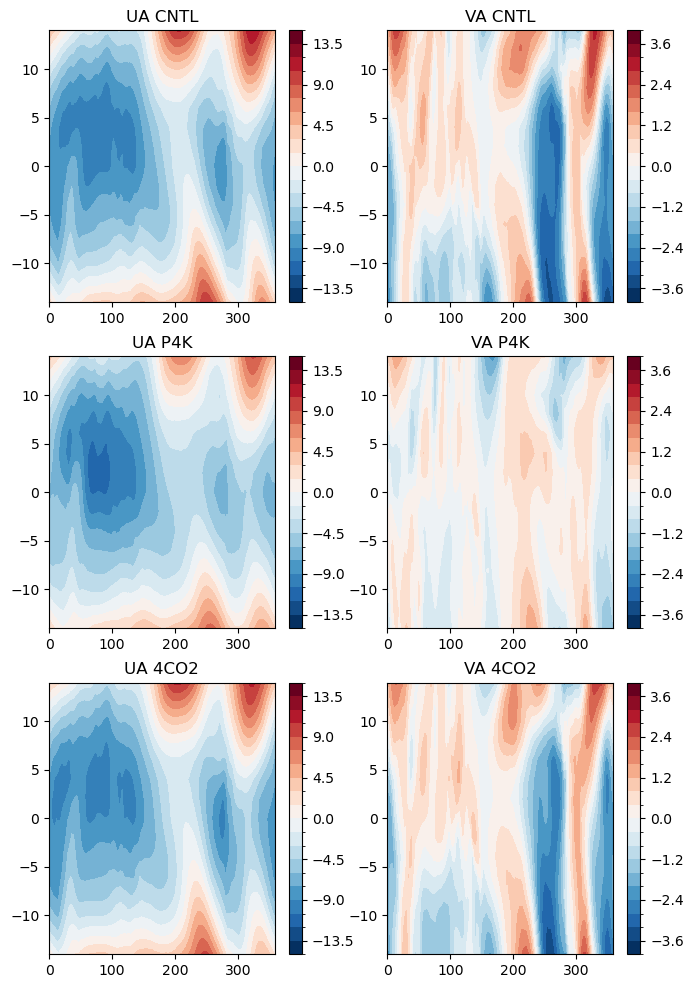

In [5]:

fig,ax = plt.subplots(3,2, figsize=(8,12))
ds_ua_cntl.ua.mean('time').plot.contourf(ax=ax[0,0],add_labels=False,levels=np.linspace(-15,15,21)    )
ax[0,0].set_title('UA CNTL')
ds_ua_p4k.ua.mean('time').plot.contourf(ax=ax[1,0],add_labels=False,levels=np.linspace(-15,15,21)    )
ax[1,0].set_title('UA P4K')
ds_va_cntl.va.mean('time').plot.contourf(ax=ax[0,1],add_labels=False,levels=np.linspace(-4,4,21)   )
ax[0,1].set_title('VA CNTL')
ds_va_p4k.va.mean('time').plot.contourf(ax=ax[1,1],add_labels=False,levels=np.linspace(-4,4,21)    )
ax[1,1].set_title('VA P4K')
ds_ua_4co2.ua.mean('time').plot.contourf(ax=ax[2,0],add_labels=False,levels=np.linspace(-15,15,21)   )
ax[2,0].set_title('UA 4CO2')
ds_va_4co2.va.mean('time').plot.contourf(ax=ax[2,1],add_labels=False,levels=np.linspace(-4,4,21)   )
ax[2,1].set_title('VA 4CO2')

# xr.open_dataset(r'/work/mh1498/m301257/3D_data/cntl/ua_all_levels.nc').sel(level=55).ua.mean('time').plot.contourf()

In [6]:
def compute_grid_spacing(lat: np.ndarray, lon: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """计算网格间距 (m)"""
    R = 6.371e6  # 地球半径
    xlon, ylat = np.meshgrid(lon, lat)
    dlonx = np.gradient(xlon, axis=1)
    dlaty = np.gradient(ylat, axis=0)
    dx = R * np.cos(ylat * np.pi / 180) * dlonx * np.pi / 180
    dy = R * dlaty * np.pi / 180
    return dx, dy
dx,dy = compute_grid_spacing(ds_ua_cntl.lat.values, ds_ua_cntl.lon.values)

In [ ]:
def numpy_divergence(u: xr.DataArray, v: xr.DataArray, dx: np.ndarray, dy: np.ndarray) -> np.ndarray:
    """使用 NumPy 计算散度"""
    du_dx = np.gradient(u, axis=-1) / dx[np.newaxis, :, :]
    dv_dy = np.gradient(v, axis=-2) / dy[np.newaxis, :, :]
    return (du_dx + dv_dy)


def compute_divergence_chunked(u: xr.DataArray, v: xr.DataArray, 
                               dx: np.ndarray, dy: np.ndarray, 
                               time_chunk_size: int = 100) -> xr.DataArray:
    """
    分块计算散度，避免内存溢出
    
    Parameters:
    -----------
    u, v : xr.DataArray
        u 和 v 风速分量
    dx, dy : np.ndarray
        网格间距
    time_chunk_size : int
        每次处理的时间步数
    
    Returns:
    --------
    xr.DataArray
        散度场
    """
    print(f"\n🔄 开始分块计算散度 (每块 {time_chunk_size} 个时间步)...")
    
    n_times = len(u.time)
    n_chunks = int(np.ceil(n_times / time_chunk_size))
    
    print(f"   总时间步数: {n_times}")
    print(f"   分块数量: {n_chunks}")
    
    div_chunks = []
    
    for i in range(n_chunks):
        start_idx = i * time_chunk_size
        end_idx = min((i + 1) * time_chunk_size, n_times)
        
        print(f"   处理块 {i+1}/{n_chunks} (时间步 {start_idx}-{end_idx})...", end=' ')
        
        # 提取当前块的数据
        u_chunk = u.isel(time=slice(start_idx, end_idx)).compute()
        v_chunk = v.isel(time=slice(start_idx, end_idx)).compute()
        
        # 计算散度
        div_chunk = numpy_divergence(u_chunk, v_chunk, dx, dy)
        div_chunks.append(div_chunk)
        
        print(f"✓")
        
        # 清理内存
        del u_chunk, v_chunk
        gc.collect()
    
    # 合并所有块
    print("   合并所有块...")
    div_all = np.concatenate(div_chunks, axis=0)
    
    # 转换为 xarray DataArray
    div_da = xr.DataArray(div_all, coords=u.coords, dims=u.dims)
    
    print("✅ 散度计算完成\n")
    
    # 清理临时数据
    del div_chunks, div_all
    gc.collect()
    
    return div_da


mem_monitor.print_memory_status("散度计算前")

# 使用分块计算散度
div_cntl = compute_divergence_chunked(ds_ua_cntl.ua, ds_va_cntl.va, dx, dy, time_chunk_size=100)
mem_monitor.print_memory_status("CNTL 散度计算后")

div_p4k = compute_divergence_chunked(ds_ua_p4k.ua, ds_va_p4k.va, dx, dy, time_chunk_size=100)
mem_monitor.print_memory_status("P4K 散度计算后")

div_4co2 = compute_divergence_chunked(ds_ua_4co2.ua, ds_va_4co2.va, dx, dy, time_chunk_size=100)
mem_monitor.print_memory_status("4CO2 散度计算后")



💾 内存状态 - 散度计算前
  进程物理内存使用: 1.60 GB
  进程虚拟内存使用: 23.45 GB
  进程内存占比: 0.3%
  系统可用内存: 200.66 GB / 501.87 GB


🔄 开始分块计算散度 (每块 100 个时间步)...
   总时间步数: 5114
   分块数量: 52
   处理块 1/52 (时间步 0-100)... ✓
   处理块 2/52 (时间步 100-200)... ✓
   处理块 3/52 (时间步 200-300)... ✓
   处理块 4/52 (时间步 300-400)... ✓
✓
   处理块 3/52 (时间步 200-300)... ✓
   处理块 4/52 (时间步 300-400)... ✓
   处理块 5/52 (时间步 400-500)... ✓
   处理块 6/52 (时间步 500-600)... ✓
   处理块 5/52 (时间步 400-500)... ✓
   处理块 6/52 (时间步 500-600)... ✓
   处理块 7/52 (时间步 600-700)... ✓
   处理块 8/52 (时间步 700-800)... ✓
   处理块 7/52 (时间步 600-700)... ✓
   处理块 8/52 (时间步 700-800)... ✓
   处理块 9/52 (时间步 800-900)... ✓
   处理块 10/52 (时间步 900-1000)... ✓
   处理块 9/52 (时间步 800-900)... ✓
   处理块 10/52 (时间步 900-1000)... ✓
   处理块 11/52 (时间步 1000-1100)... ✓
   处理块 12/52 (时间步 1100-1200)... ✓
   处理块 11/52 (时间步 1000-1100)... ✓
   处理块 12/52 (时间步 1100-1200)... ✓
   处理块 13/52 (时间步 1200-1300)... ✓
   处理块 14/52 (时间步 1300-1400)... ✓
   处理块 13/52 (时间步 1200-1300)... ✓
   处理块 14/52 (时间步 1300-1400)... ✓
   处理

{'rss_gb': 1.9102783203125,
 'vms_gb': 23.762508392333984,
 'percent': 0.3806306368791492,
 'available_gb': 200.3482551574707,
 'total_gb': 501.8719291687012}

Text(0.5, 1.0, 'Divergence 4CO2')

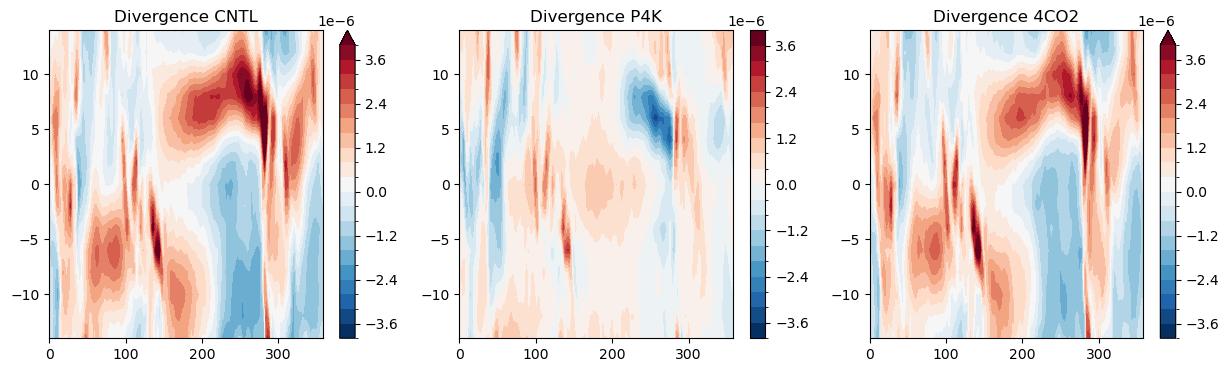

In [8]:
fig,ax = plt.subplots(1,3, figsize=(15,4))
div_cntl.mean('time').plot.contourf(ax=ax[0],levels=np.linspace(-4e-6,4e-6,21),add_labels=False)
ax[0].set_title('Divergence CNTL')
div_p4k.mean('time').plot.contourf(ax=ax[1],levels=np.linspace(-4e-6,4e-6,21),add_labels=False)
ax[1].set_title('Divergence P4K')
div_4co2.mean('time').plot.contourf(ax=ax[2],levels=np.linspace(-4e-6,4e-6,21),add_labels=False)
ax[2].set_title('Divergence 4CO2')

## cross spectrum

In [24]:
all_div = {'cntl': div_cntl, 'p4k': div_p4k, '4co2': div_4co2}
all_div

{'cntl': <xarray.DataArray (time: 5114, lat: 15, lon: 180)> Size: 110MB
 array([[[ 9.91245653e-06,  4.87264885e-07,  2.60818286e-06, ...,
          -7.13361213e-06, -7.55391181e-06,  2.01137354e-06],
         [ 3.56574898e-06, -1.07305246e-06, -6.09173838e-07, ...,
          -4.73707053e-06,  3.87045328e-07,  8.93291926e-06],
         [ 1.04671954e-05,  4.88341148e-06, -4.07529185e-06, ...,
           3.29075724e-06,  6.43502882e-07,  8.93942054e-09],
         ...,
         [ 1.39852655e-05,  1.41200516e-05,  5.04884958e-06, ...,
          -6.78766712e-06, -4.39302661e-06, -1.93939662e-06],
         [ 1.11730851e-05,  1.11933069e-05, -1.86244746e-06, ...,
           1.64663355e-06, -2.18369692e-06, -9.72314275e-06],
         [-1.17925140e-05,  2.34752929e-07, -1.13968114e-08, ...,
           9.86672354e-08, -1.44186405e-06, -7.35035415e-06]],
 
        [[ 2.55586976e-06,  4.78958406e-06,  3.26977302e-06, ...,
           4.90938554e-06, -1.79912911e-06,  1.56190696e-06],
         [-2.44

In [28]:
all_pr = load_all_precipitation_data()
all_pr


加载所有降水数据

💾 内存状态 - 加载降水数据前
  进程物理内存使用: 14.89 GB
  进程虚拟内存使用: 39.41 GB
  进程内存占比: 3.0%
  系统可用内存: 201.03 GB / 501.87 GB


加载 CNTL...
📂 加载数据: /work/mh1498/m301257/data_origin/pr_cntl_2deg_interp.nc
✅ 数据加载成功 (lazy loading)
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   数据块: ((100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 14), (15,), (180,))
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   估算数据大小: 0.10 GB

加载 P4K...
📂 加载数据: /work/mh1498/m301257/data_origin/pr_p4k_2deg_interp.nc
✅ 数据加载成功 (lazy loading)
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   数据块: ((100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 10

{'cntl': <xarray.DataArray (time: 5114, lat: 15, lon: 180)> Size: 110MB
 dask.array<open_dataset-__xarray_dataarray_variable__, shape=(5114, 15, 180), dtype=float64, chunksize=(100, 15, 180), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
   * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
   * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0,
 'p4k': <xarray.DataArray (time: 5114, lat: 15, lon: 180)> Size: 110MB
 dask.array<open_dataset-__xarray_dataarray_variable__, shape=(5114, 15, 180), dtype=float64, chunksize=(100, 15, 180), chunktype=numpy.ndarray>
 Coordinates:
   * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
   * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
   * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0,
 '4co2': <xarray.DataArray (time: 5114, lat: 15, lon: 180)> Siz

In [29]:
# ============ 网格对齐函数 ============

def align_grids(pr_data, div_data):
    """
    确保降水和散度数据在相同的网格上
    
    Parameters:
    -----------
    pr_data : xr.DataArray
        降水数据
    div_data : xr.DataArray
        散度数据
    
    Returns:
    --------
    tuple : (pr_aligned, div_aligned)
        对齐后的降水和散度数据
    """
    print(f"  原始形状: pr={pr_data.shape}, div={div_data.shape}")
    
    # 检查经度维度
    pr_lon = pr_data.lon.values
    div_lon = div_data.lon.values
    
    if len(pr_lon) != len(div_lon):
        print(f"  ⚠️ 经度维度不匹配: pr有{len(pr_lon)}个点, div有{len(div_lon)}个点")
        print(f"  🔧 将散度数据插值到降水网格...")
        
        # 将散度数据插值到降水的网格，使用最近邻以避免边界NaN
        div_aligned = div_data.interp(lon=pr_data.lon, lat=pr_data.lat, 
                                      method='linear', 
                                      kwargs={'fill_value': 'extrapolate'})
        
        # 检查并处理NaN值
        nan_count_before = np.isnan(div_aligned.values).sum()
        if nan_count_before > 0:
            print(f"  ⚠️ 插值后发现 {nan_count_before} 个NaN值，进行填充...")
            # 使用最近邻填充剩余的NaN
            div_aligned = div_aligned.fillna(div_data.interp(lon=pr_data.lon, lat=pr_data.lat, 
                                                              method='nearest'))
            nan_count_after = np.isnan(div_aligned.values).sum()
            print(f"  ✓ 填充后剩余 {nan_count_after} 个NaN值")
            
            # 如果还有NaN，用0填充（极端情况）
            if nan_count_after > 0:
                div_aligned = div_aligned.fillna(0)
                print(f"  ✓ 剩余NaN值已用0填充")
    else:
        div_aligned = div_data
    
    print(f"  对齐后形状: pr={pr_data.shape}, div={div_aligned.shape}")
    
    return pr_data, div_aligned

In [30]:
def _ocean(ds):
    fraction = xr.open_dataarray(r'../processed_data/land_mask_2deg.nc')
    return fraction == 0
ocean_mask = _ocean(None)

In [31]:
crossspectrum_55_results = {}
for exp_name in ['cntl', 'p4k', '4co2']:
    print(f"\n  处理 {exp_name.upper()}...")
    
    # 获取降水和散度数据
    pr_raw = all_pr[exp_name]
    div_raw = all_div[exp_name]
    
    # 网格对齐 - 确保降水和散度在相同网格上
    pr_aligned, div_aligned = align_grids(pr_raw, div_raw)
    
    # 计算异常值（去除年循环）
    pr_ano = pr_aligned.groupby('time.dayofyear') - pr_aligned.groupby('time.dayofyear').mean()
    div_ano = div_aligned.groupby('time.dayofyear') - div_aligned.groupby('time.dayofyear').mean()
    
    # 应用海洋掩码并填充NaN（用0填充以避免交叉谱计算出错）
    pr_ano = pr_ano.where(ocean_mask, 0)
    div_ano = div_ano.where(ocean_mask, 0)
    
    # 计算交叉谱 - 使用wave_tools的函数
    result = calculate_cross_spectrum(
        pr_ano, div_ano, 
        segLen=96, 
        segOverLap=-65,
        symmetry='symm',
        return_xarray=True
    )
    
    # 提取结果（现在result['STC']已经是xarray DataArray）
    if result is None:
        print(f"    ✗ 交叉谱计算失败，返回None")
        continue
        
    stc_da = result['STC']  # 已经是xarray DataArray
    zonalwnum = result['wave']
    freq = result['freq']
    stc = stc_da.values  # 如果需要numpy数组
    
    # 存储结果 - stc_da已经是正确格式，不需要再次转换
    crossspectrum_55_results[exp_name] = {
        'STC': stc_da,  # 直接使用返回的DataArray
        'freq': freq,
        'wave': zonalwnum,
        'nseg': result['nseg'],
        'dof': result['dof'],
        'p': result['p'],
        'prob_coh2': result['prob_coh2']
    }


  处理 CNTL...
  原始形状: pr=(5114, 15, 180), div=(5114, 15, 180)
  对齐后形状: pr=(5114, 15, 180), div=(5114, 15, 180)

  处理 P4K...
  原始形状: pr=(5114, 15, 180), div=(5114, 15, 180)
  对齐后形状: pr=(5114, 15, 180), div=(5114, 15, 180)

  处理 4CO2...
  原始形状: pr=(5114, 15, 180), div=(5114, 15, 180)
  对齐后形状: pr=(5114, 15, 180), div=(5114, 15, 180)


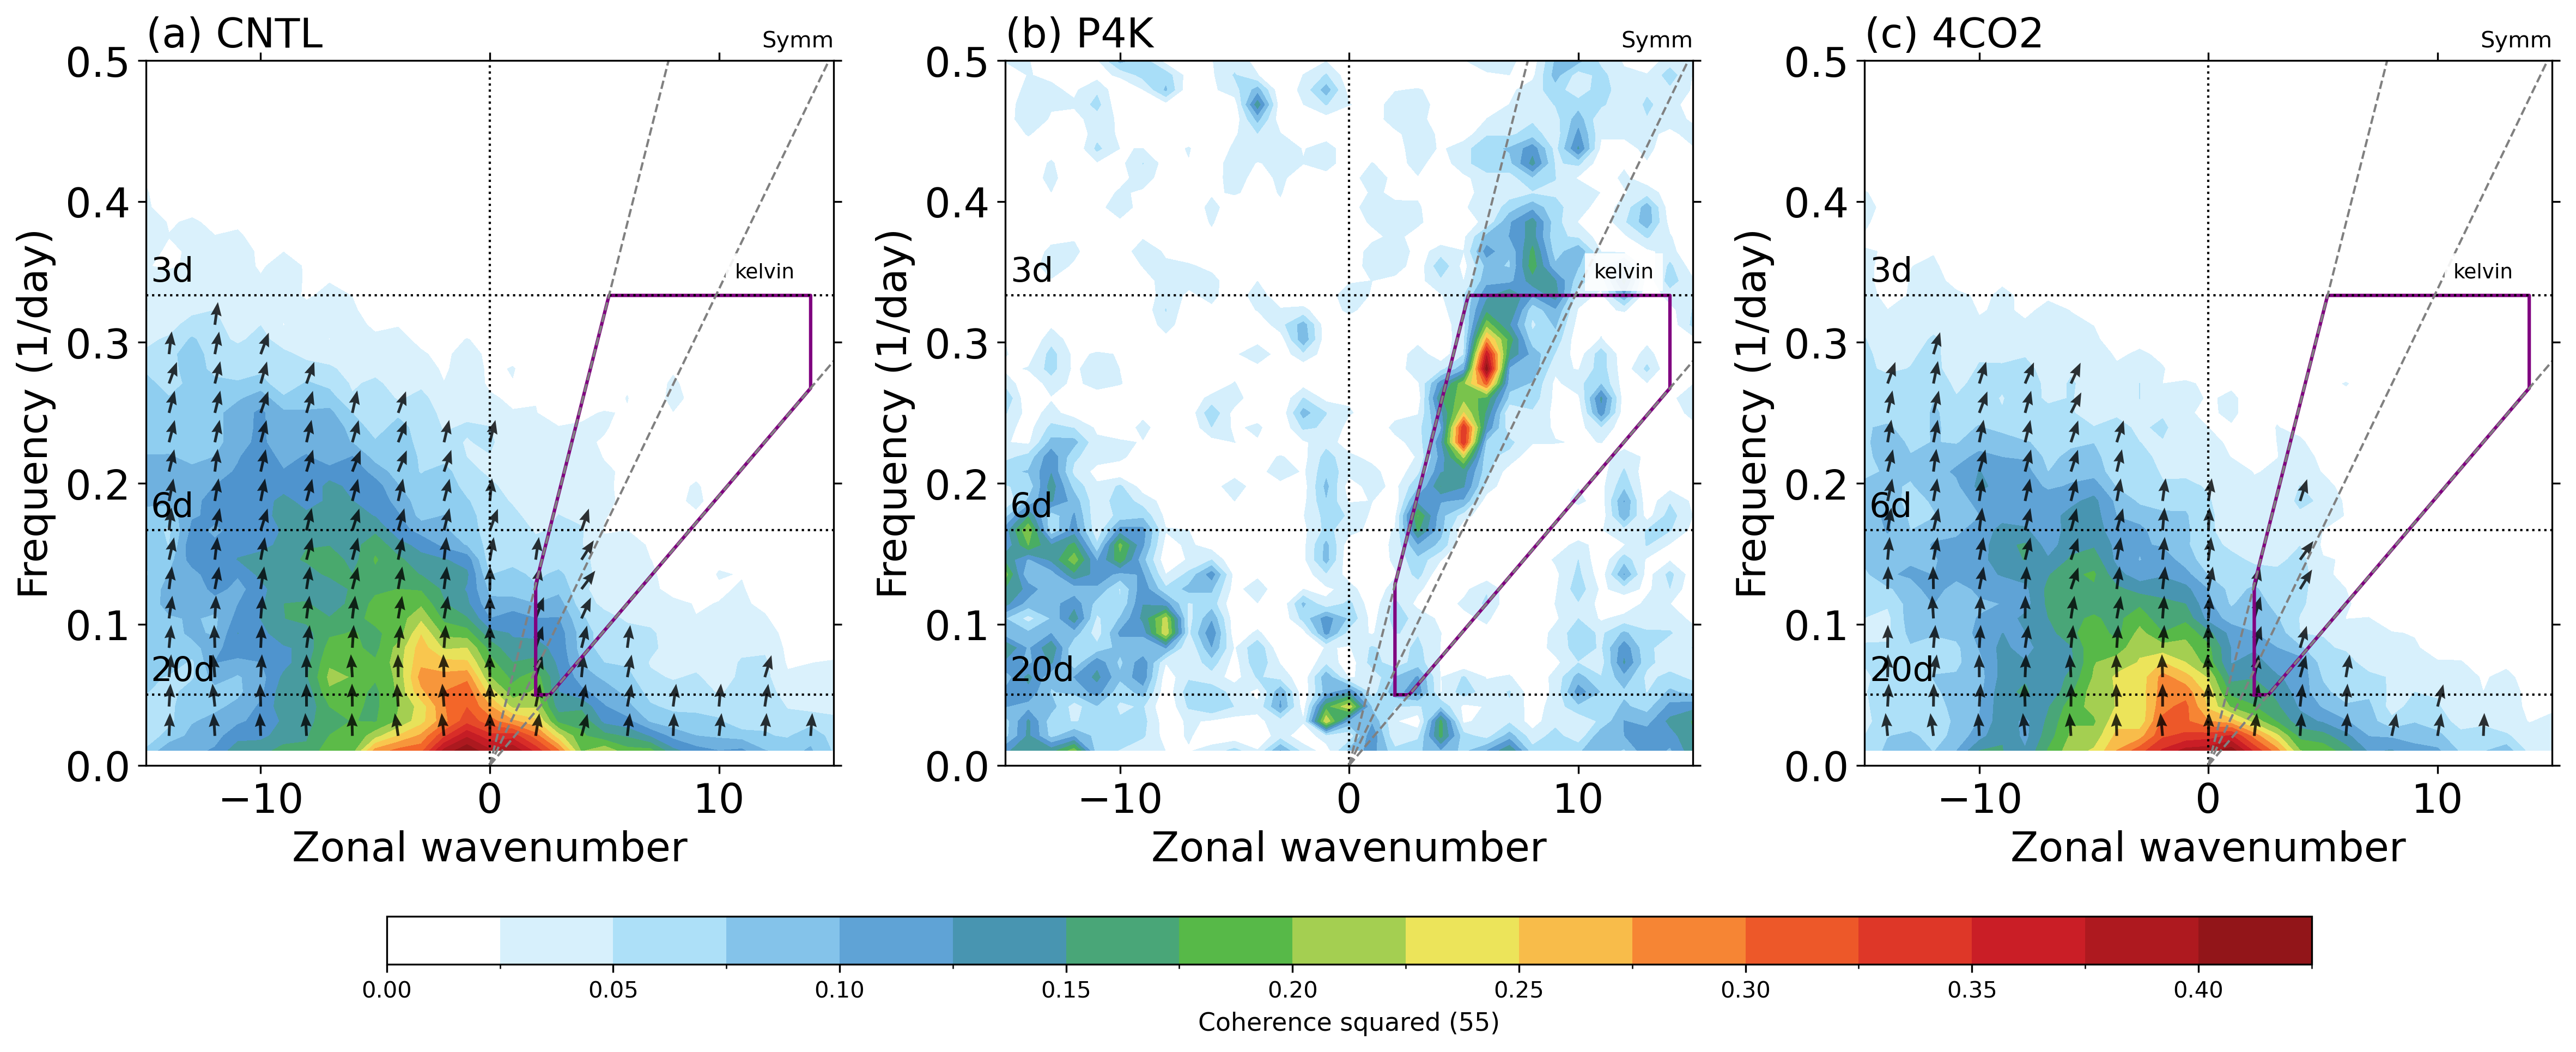

In [36]:
s2d = 86400
re = 6371 * 1000

# 创建3个子图
fig, axes = plt.subplots(1, 3, figsize=(16, 8), dpi=300)
plt.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.15, wspace=0.25)
plt.rcParams.update({'font.size': 10})

exp_names = ['cntl', 'p4k', '4co2']
exp_titles = ['CNTL', 'P4K', '4CO2']

# 设置coherence²阈值
coh2_threshold = 0.05

for idx, (exp_name, exp_title, ax) in enumerate(zip(exp_names, exp_titles, axes)):
    plt.sca(ax)

    # 获取当前实验的结果
    stc = crossspectrum_55_results[exp_name]['STC']
    zonalwnum = crossspectrum_55_results[exp_name]['wave']
    freq = crossspectrum_55_results[exp_name]['freq']

    # 绘制coherence squared的等高线图
    # 使用sel来选择component维度
    contourf = stc.sel(component='COH2').plot.contourf(
        ax=ax,
        cmap=cmaps.WhiteBlueGreenYellowRed,
        levels=21,
        add_colorbar=False,
        add_labels=False,
        extend='neither'
    )

    # 准备矢量场数据
    skip = 2
    wave_sub = zonalwnum[::skip]
    freq_sub = freq[::skip]
    u_sub = stc.sel(component='V1').values[::skip, ::skip]
    v_sub = stc.sel(component='V2').values[::skip, ::skip]
    coh2_sub = stc.sel(component='COH2').values[::skip, ::skip]

    # 创建掩蔽
    mask = coh2_sub < coh2_threshold
    u_masked = np.where(mask, np.nan, u_sub)
    v_masked = np.where(mask, np.nan, v_sub)

    # 添加矢量场
    q = ax.quiver(
        wave_sub, freq_sub,
        u_masked, v_masked,
        scale=30, headwidth=4, headlength=5, 
        width=0.004, alpha=0.8
    )

    # 设置标题
    ax.set_title(f'({chr(97 + idx)}) {exp_title}', fontsize=18, loc='left')
    ax.set_title(f'Symm', fontsize=10, loc='right')

    # 设置坐标轴
    ax.set_ylabel('Frequency (1/day)', fontsize=18)
    ax.set_xlabel('Zonal wavenumber', fontsize=18)
    ax.set_xlim(-15, 15)
    ax.set_ylim(0, 0.5)
    kw_x, kw_y = get_curve()
    # 绘制CCKW波段
    ax.plot(kw_x[0], kw_y[0], 'purple', linewidth=1.5, linestyle='solid', label='CCKW band')

    # 添加参考线
    d = np.array([3, 6, 20])
    dname = ['3d', '6d', '20d']
    he_all = np.array([8, 25, 90])
    cp = (9.8 * he_all) ** 0.5
    zwnum_goal = 0.5 / s2d / cp * 2 * np.pi * re

    # 零波数线
    ax.plot([0, 0], [0, 0.5], 'k', linewidth=1, linestyle=':')

    # 周期线
    for dd in range(len(d)):
        ax.plot([-15, 15], [1/d[dd], 1/d[dd]], 'k', linewidth=1, linestyle=':')
        ax.text(-14.8, 1/d[dd] + 0.01, dname[dd], fontsize=15, color='k')

    # Kelvin波色散关系
    for hh in range(len(he_all)):
        ax.plot([0, zwnum_goal[hh]], [0, 0.5], 'grey', linewidth=1, linestyle='dashed')

    # 添加"kelvin"标签
    ax.text(12, 0.35, 'kelvin', ha="center", va="center", size=9,
            bbox={'facecolor': 'w', 'alpha': 0.9, 'edgecolor': 'none'})
    ax.tick_params(labelsize=18, which='both', top=True, right=True)

    # # 添加颜色条
cbar = fig.colorbar(contourf, ax=axes, orientation='horizontal', 
                    pad=0.15, aspect=40, shrink=0.8)
cbar.set_label('Coherence squared (55)', fontsize=11)
            

## check origin data

In [9]:
import intake

def main(client=None, time_chunk_size=365):
    """
    主函数：处理数据并返回结果 (优化版，使用分块计算)
    
    Parameters:
    -----------
    client : dask.distributed.Client, optional
        Dask 客户端，用于并行计算
    time_chunk_size : int
        每次处理的时间步数，默认365 (1年)
    """
    mem_monitor.print_memory_status("主函数开始")
    
    print("🚀 开始加载数据...")
    
    cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
    ds = cat.ICON.C5["AMIP_P4K"].to_dask()
    
    print("📊 选择数据切片...")
    ua = ds.ua.sel(level_half=55, time=slice('1980', '1993'))
    va = ds.va.sel(level_half=55, time=slice('1980', '1993'))
    
    print(f"   UA 数据形状: {ua.shape}")
    print(f"   VA 数据形状: {va.shape}")
    
    mem_monitor.print_memory_status("数据选择后")
    
    print("🌍 转换到经纬度网格 (分块处理)...")
    grid_dict = {"nside": 256, "nest": True, "minmax_lat": 20}
    
    # 获取时间维度大小
    n_times = len(ua.time)
    n_chunks = int(np.ceil(n_times / time_chunk_size))
    
    print(f"   总时间步数: {n_times}")
    print(f"   分块数量: {n_chunks} (每块 {time_chunk_size} 步)")
    
    ua_chunks = []
    va_chunks = []
    
    for i in range(n_chunks):
        start_idx = i * time_chunk_size
        end_idx = min((i + 1) * time_chunk_size, n_times)
        
        print(f"\n   处理块 {i+1}/{n_chunks} (时间步 {start_idx}-{end_idx})...")
        
        # 提取当前块
        ua_chunk = ua.isel(time=slice(start_idx, end_idx))
        va_chunk = va.isel(time=slice(start_idx, end_idx))
        
        # 转换到经纬度网格
        print(f"      - 转换 UA 到经纬度...")
        ua_lon_lat_chunk = dataarray_to_equatorial_latlon_grid(ua_chunk, 'healpix', grid_dict)
        
        print(f"      - 转换 VA 到经纬度...")
        va_lon_lat_chunk = dataarray_to_equatorial_latlon_grid(va_chunk, 'healpix', grid_dict)
        
        # 插值到2度网格
        print(f"      - 插值到2度网格...")
        target_lat = np.arange(-20, 20.1, 2.0)
        target_lon = np.arange(0, 360, 2.0)
        
        ua_2deg_chunk = ua_lon_lat_chunk.interp(lat=target_lat, lon=target_lon)
        va_2deg_chunk = va_lon_lat_chunk.interp(lat=target_lat, lon=target_lon)
        
        # 计算并存储（释放 dask 的懒加载）
        print(f"      - 计算数据...")
        ua_2deg_chunk = ua_2deg_chunk.compute()
        va_2deg_chunk = va_2deg_chunk.compute()
        
        ua_chunks.append(ua_2deg_chunk)
        va_chunks.append(va_2deg_chunk)
        
        print(f"      ✓ 块 {i+1} 完成")
        
        # 清理内存
        del ua_chunk, va_chunk, ua_lon_lat_chunk, va_lon_lat_chunk
        gc.collect()
        
        mem_monitor.print_memory_status(f"块 {i+1}/{n_chunks} 处理后")
    
    # 合并所有块
    print("\n🔗 合并所有数据块...")
    ua_var_2deg = xr.concat(ua_chunks, dim='time')
    va_var_2deg = xr.concat(va_chunks, dim='time')
    
    # 清理临时数据
    del ua_chunks, va_chunks
    gc.collect()
    
    print("✅ 数据处理完成!")
    mem_monitor.print_memory_status("主函数结束")
    
    return ua_var_2deg, va_var_2deg


In [10]:
# ============ 额外的内存管理工具 ============

def clean_memory():
    """清理内存并打印清理前后的状态"""
    print("\n🧹 清理内存...")
    mem_before = mem_monitor.get_memory_info()
    
    # 强制垃圾回收
    collected = gc.collect()
    
    mem_after = mem_monitor.get_memory_info()
    
    freed_mb = (mem_before['rss_gb'] - mem_after['rss_gb']) * 1024
    
    print(f"   回收对象数: {collected}")
    print(f"   释放内存: {freed_mb:.1f} MB")
    print(f"   当前内存使用: {mem_after['rss_gb']:.2f} GB")
    print(f"   系统可用内存: {mem_after['available_gb']:.2f} GB\n")
    
    return mem_after


def estimate_array_memory(shape, dtype=np.float64):
    """估算数组所需内存"""
    itemsize = np.dtype(dtype).itemsize
    total_bytes = np.prod(shape) * itemsize
    total_gb = total_bytes / 1024**3
    return total_gb


def check_memory_available(required_gb, safety_margin=5.0):
    """
    检查是否有足够的可用内存
    
    Parameters:
    -----------
    required_gb : float
        需要的内存 (GB)
    safety_margin : float
        安全边际 (GB)
    
    Returns:
    --------
    bool
        是否有足够内存
    """
    info = mem_monitor.get_memory_info()
    available = info['available_gb']
    
    if available < required_gb + safety_margin:
        print(f"⚠️  警告: 可用内存不足!")
        print(f"   需要: {required_gb:.2f} GB")
        print(f"   可用: {available:.2f} GB")
        print(f"   建议: 至少需要 {required_gb + safety_margin:.2f} GB")
        return False
    else:
        print(f"✅ 内存充足")
        print(f"   需要: {required_gb:.2f} GB")
        print(f"   可用: {available:.2f} GB")
        return True


# 测试内存管理工具
print("="*60)
print("内存管理工具测试")
print("="*60)

# 显示当前内存状态
mem_monitor.print_memory_status("工具测试")

# 测试内存估算
print("\n📏 数组内存估算示例:")
example_shape = (5113, 21, 180)  # 示例：14年日数据，21个纬度，180个经度
estimated_gb = estimate_array_memory(example_shape)
print(f"   数组形状: {example_shape}")
print(f"   估算大小: {estimated_gb:.3f} GB")

# 检查是否有足够内存
check_memory_available(estimated_gb)


内存管理工具测试

💾 内存状态 - 工具测试
  进程物理内存使用: 1.92 GB
  进程虚拟内存使用: 23.77 GB
  进程内存占比: 0.4%
  系统可用内存: 200.14 GB / 501.87 GB


📏 数组内存估算示例:
   数组形状: (5113, 21, 180)
   估算大小: 0.144 GB
✅ 内存充足
   需要: 0.14 GB
   可用: 200.14 GB


True

In [11]:
# ============ 使用示例 ============

# 示例1: 加载降水数据（带内存监控）
all_pr = load_all_precipitation_data(chunks={'time': 100})

# 示例2: 如果内存不足，可以使用更小的块
all_pr = load_all_precipitation_data(chunks={'time': 50})

# 示例3: 手动清理内存
clean_memory()

# 示例4: 调用主函数（如需要从 intake 加载数据）
# 默认每次处理365个时间步（约1年）
ua_2deg, va_2deg = main(time_chunk_size=365)

# 如果内存不足，减小分块大小
# ua_2deg, va_2deg = main(time_chunk_size=180)  # 半年一块

print("💡 提示: 取消注释上面的代码来运行相应的功能")
print("   根据你的内存情况调整 time_chunk_size 参数")



加载所有降水数据

💾 内存状态 - 加载降水数据前
  进程物理内存使用: 1.92 GB
  进程虚拟内存使用: 23.77 GB
  进程内存占比: 0.4%
  系统可用内存: 200.14 GB / 501.87 GB


加载 CNTL...
📂 加载数据: /work/mh1498/m301257/data_origin/pr_cntl_2deg_interp.nc
✅ 数据加载成功 (lazy loading)
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   数据块: ((100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 14), (15,), (180,))
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   估算数据大小: 0.10 GB

加载 P4K...
📂 加载数据: /work/mh1498/m301257/data_origin/pr_p4k_2deg_interp.nc
✅ 数据加载成功 (lazy loading)
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   数据块: ((100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100

/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


📊 选择数据切片...
   UA 数据形状: (5114, 786432)
   VA 数据形状: (5114, 786432)

💾 内存状态 - 数据选择后
  进程物理内存使用: 2.15 GB
  进程虚拟内存使用: 24.15 GB
  进程内存占比: 0.4%
  系统可用内存: 199.91 GB / 501.87 GB

🌍 转换到经纬度网格 (分块处理)...
   总时间步数: 5114
   分块数量: 15 (每块 365 步)

   处理块 1/15 (时间步 0-365)...
      - 转换 UA 到经纬度...
DEBUG: Total pixels: 786432
DEBUG: Lat range: -89.82 to 89.82
DEBUG: Lon range: 0.00 to 359.82
DEBUG: Unique latitudes in range: 263
DEBUG: Reference latitude: -19.95, with 1024 longitude points
  Lat -19.9467: 1024 points, target: 1024 points
DEBUG: Total pixels: 786432
DEBUG: Lat range: -89.82 to 89.82
DEBUG: Lon range: 0.00 to 359.82
DEBUG: Unique latitudes in range: 263
DEBUG: Reference latitude: -19.95, with 1024 longitude points
  Lat -19.9467: 1024 points, target: 1024 points
  Lat -19.7880: 1024 points, target: 1024 points
  Lat -19.6296: 1024 points, target: 1024 points
  Lat -19.7880: 1024 points, target: 1024 points
  Lat -19.6296: 1024 points, target: 1024 points
  Lat 19.9467: 1024 points, target: 

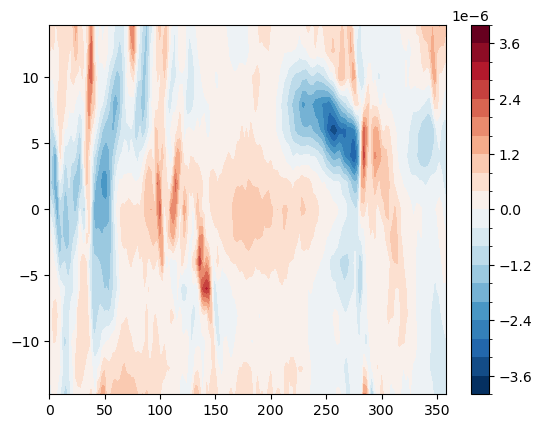

In [ ]:
ua_2deg = ua_2deg.sel(lat=slice(-15,15))
va_2deg = va_2deg.sel(lat=slice(-15,15))
div_55  = numpy_divergence(ua_2deg.values, va_2deg.values, dx, dy)
div_55  = xr.DataArray(div_55, coords=ua_2deg.coords, dims=ua_2deg.dims)
div_55.mean('time').plot.contourf(levels=np.linspace(-4e-6,4e-6,21),add_labels=False)